# 01 · Parameter sweeps

Hands-on exploration of how the multi-agent dynamics respond to the key knobs:

1. **λ sweep under discrete shift** — does high λ produce visible adaptation lag?
2. **λ × drift-rate grid** — coarse phase-diagram preview
3. **Network topology** — Watts–Strogatz rewiring effect
4. **Trust dynamics** — γ matrix evolution under different λ
5. **Population heterogeneity** — distribution of preferences C across agents

Each section is a standalone cell block; run whichever you want.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    build, ModelConfig, EnvConfig, EvolutionRegime, History, Population,
)
import pymdp
from pymdp.agent import Agent as PymdpAgent

sns.set_theme(context='notebook', style='whitegrid')


def rollout(model_cfg, env_cfg, T):
    """Build a fresh (env, pop) and roll out T steps. Returns history dict."""
    env, pop = build(model_cfg, env_cfg)
    h = History()
    for _ in range(T):
        pop, out = pop.step(env)
        h.append(out)
    return h.as_arrays(), pop

## 0. Confirm the pymdp integration

`Population` wraps a single batched `pymdp.Agent`. Every call to `pop.step(env)`
internally invokes `agent.infer_states(...)` to compute the env-channel
posterior. The cell below makes that explicit.

In [2]:
env, pop = build(ModelConfig(seed=0), EnvConfig(n_agents=30, n_contexts=1, seed=0))
print('pymdp version:        ', getattr(pymdp, '__version__', 'unknown'))
print('type(pop.agent):      ', type(pop.agent).__name__, '(from pymdp.agent)')
print('isinstance pymdp:     ', isinstance(pop.agent, PymdpAgent))
print('agent.batch_size:     ', pop.agent.batch_size)
print('agent.A[0].shape:     ', pop.agent.A[0].shape, '  (N, n_obs, n_states)')
print('agent.B[0].shape:     ', pop.agent.B[0].shape, '  (N, n_states, n_states, n_controls)')
print('agent.C[0].shape:     ', pop.agent.C[0].shape, '  (N, n_obs)  — the parameter we sweep')
print('agent.D[0].shape:     ', pop.agent.D[0].shape, '  (N, n_states)')
print()
print('A is identity:', bool(jnp.allclose(pop.agent.A[0][0], jnp.eye(2))))
print('D is uniform:', bool(jnp.allclose(pop.agent.D[0][0], 0.5)))

pymdp version:         unknown
type(pop.agent):       Agent (from pymdp.agent)
isinstance pymdp:      True
agent.batch_size:      30
agent.A[0].shape:      (30, 2, 2)   (N, n_obs, n_states)
agent.B[0].shape:      (30, 2, 2, 1)   (N, n_states, n_states, n_controls)
agent.C[0].shape:      (30, 2)   (N, n_obs)  — the parameter we sweep
agent.D[0].shape:      (30, 2)   (N, n_states)

A is identity: True
D is uniform: True


c:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:52: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


## 1. λ sweep under discrete shift

**The headline behavioural prediction.** Pre-shift everyone converges; at
$t^*=50$ the appropriate action flips; post-shift recovery time grows with λ.

Average over a few seeds to smooth out sampling noise.

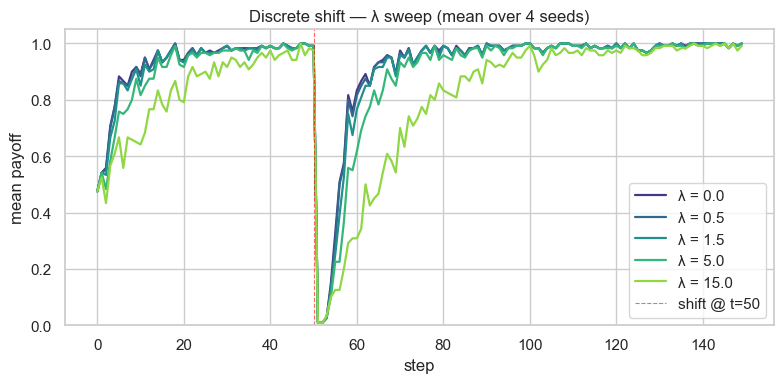

In [3]:
T = 150
shift_t = 50
lambdas = [0.0, 0.5, 1.5, 5.0, 15.0]
n_seeds = 4

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('viridis', len(lambdas))

for lam, color in zip(lambdas, colors):
    payoffs = []
    for seed in range(n_seeds):
        arrs, _ = rollout(
            ModelConfig(lambda_dist=('constant', {'value': lam}), seed=seed),
            EnvConfig(
                n_agents=30, n_contexts=1,
                regime=EvolutionRegime.DISCRETE_SHIFT,
                shift_time=shift_t, shift_contexts=(0,), seed=100 + seed,
            ),
            T,
        )
        payoffs.append(arrs['payoffs'].mean(axis=1))
    mean_curve = np.stack(payoffs).mean(axis=0)
    ax.plot(mean_curve, color=color, lw=1.6, label=f'λ = {lam}')

ax.axvline(shift_t, ls='--', c='red', lw=0.8, alpha=0.6, label=f'shift @ t={shift_t}')
ax.set(xlabel='step', ylabel='mean payoff', ylim=(0, 1.05),
       title=f'Discrete shift — λ sweep (mean over {n_seeds} seeds)')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 2. λ × drift-rate grid (phase-diagram preview)

Sweep both axes of the headline phase diagram. For each (λ, drift_step_prob),
score: how well does the population track $s^*$ on average? — `mean_payoff` in
the back half of the rollout (after warmup).

*Coarse grid for speed; refine in a dedicated experiment script for the paper.*

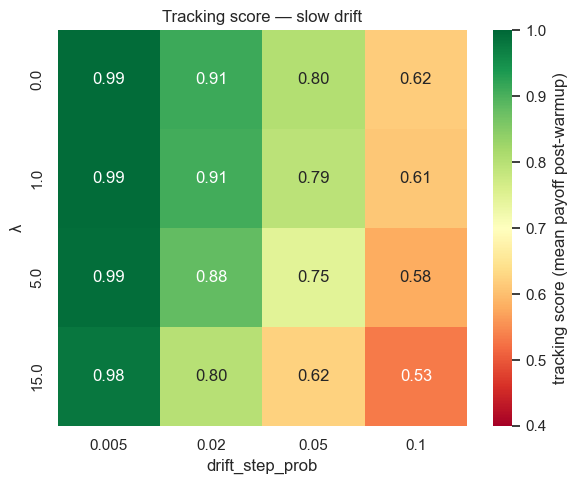

In [4]:
lambdas = [0.0, 1.0, 5.0, 15.0]
drifts = [0.005, 0.02, 0.05, 0.1]
n_seeds = 2
T = 200
warmup = 50

grid = np.zeros((len(lambdas), len(drifts)))
for i, lam in enumerate(lambdas):
    for j, drift in enumerate(drifts):
        seed_payoffs = []
        for seed in range(n_seeds):
            arrs, _ = rollout(
                ModelConfig(lambda_dist=('constant', {'value': lam}), seed=seed),
                EnvConfig(
                    n_agents=30, n_contexts=1,
                    regime=EvolutionRegime.SLOW_DRIFT,
                    drift_step_prob=drift, seed=200 + seed,
                ),
                T,
            )
            seed_payoffs.append(arrs['payoffs'][warmup:].mean())
        grid[i, j] = np.mean(seed_payoffs)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    grid,
    annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
    xticklabels=drifts, yticklabels=lambdas,
    cbar_kws={'label': 'tracking score (mean payoff post-warmup)'},
    ax=ax,
)
ax.set(xlabel='drift_step_prob', ylabel='λ', title='Tracking score — slow drift')
plt.tight_layout()
plt.show()

## 3. Network topology effect

Watts–Strogatz rewiring `p` from 0 (clean ring lattice, all local) to 1
(random graph). Same λ, same env. Does topology matter?

c:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:52: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


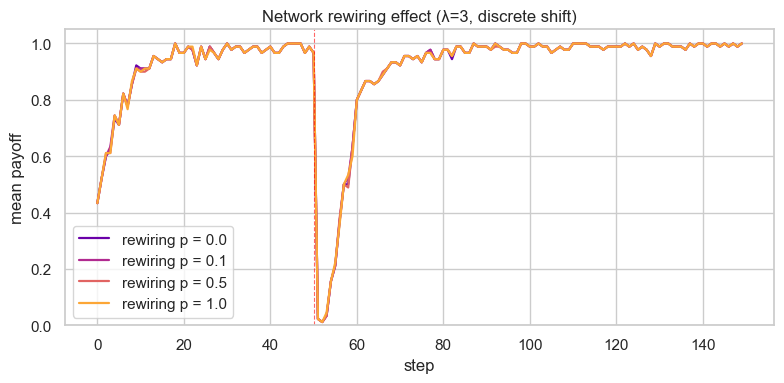

In [5]:
T = 150
shift_t = 50
rewiring_ps = [0.0, 0.1, 0.5, 1.0]
n_seeds = 3

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('plasma', len(rewiring_ps))

for rp, color in zip(rewiring_ps, colors):
    payoffs = []
    for seed in range(n_seeds):
        arrs, _ = rollout(
            ModelConfig(
                lambda_dist=('constant', {'value': 3.0}),
                rewiring_p=rp, seed=seed,
            ),
            EnvConfig(
                n_agents=30, n_contexts=1,
                regime=EvolutionRegime.DISCRETE_SHIFT,
                shift_time=shift_t, shift_contexts=(0,), seed=300 + seed,
            ),
            T,
        )
        payoffs.append(arrs['payoffs'].mean(axis=1))
    mean_curve = np.stack(payoffs).mean(axis=0)
    ax.plot(mean_curve, color=color, lw=1.6, label=f'rewiring p = {rp}')

ax.axvline(shift_t, ls='--', c='red', lw=0.8, alpha=0.6)
ax.set(xlabel='step', ylabel='mean payoff', ylim=(0, 1.05),
       title='Network rewiring effect (λ=3, discrete shift)')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 4. Trust dynamics — γ matrix evolution

Snapshot the trust matrix at three times across a stationary rollout. Off-edge
cells stay at zero; on-edge cells diverge as agents accumulate evidence about
which neighbours are reliable predictors.

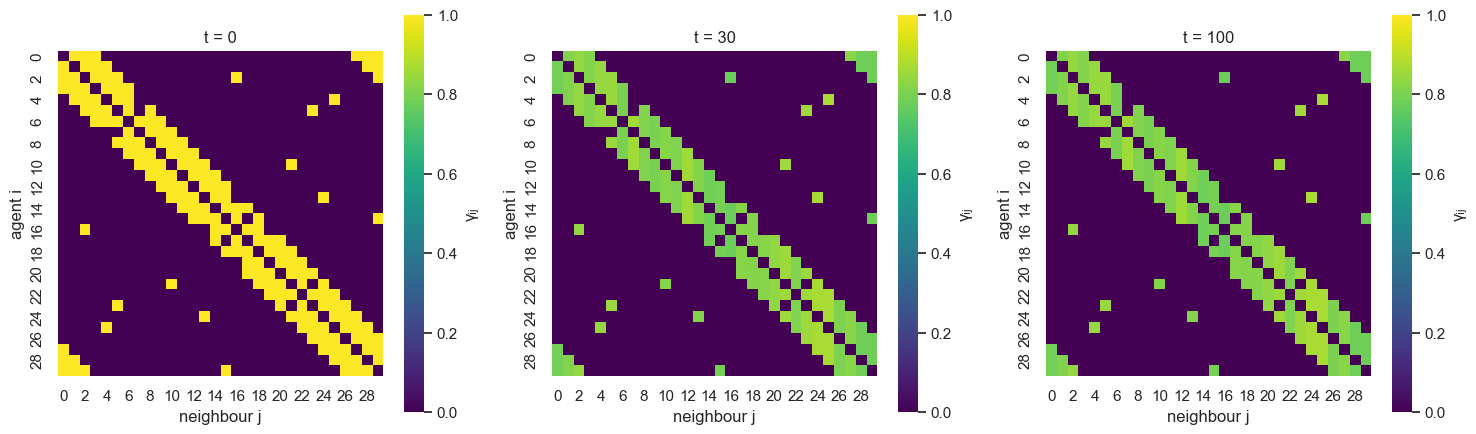

In [6]:
env, pop = build(
    ModelConfig(lambda_dist=('constant', {'value': 1.0}), seed=0),
    EnvConfig(n_agents=30, n_contexts=1, seed=0),
)
snapshots = {}
for t in range(101):
    if t in (0, 30, 100):
        snapshots[t] = np.asarray(pop.gamma)
    pop, _ = pop.step(env)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmax = max(s.max() for s in snapshots.values())
for ax, (t, gamma) in zip(axes, snapshots.items()):
    sns.heatmap(
        gamma, cmap='viridis', square=True, vmin=0, vmax=vmax,
        cbar_kws={'label': 'γᵢⱼ'}, ax=ax,
    )
    ax.set(xlabel='neighbour j', ylabel='agent i', title=f't = {t}')
plt.tight_layout()
plt.show()

## 5. Population heterogeneity — C distribution across agents

Show how preferences C diverge or stay clustered as agents accumulate evidence,
comparing low-λ (loose population) and high-λ (entrenched population).

c:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:52: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


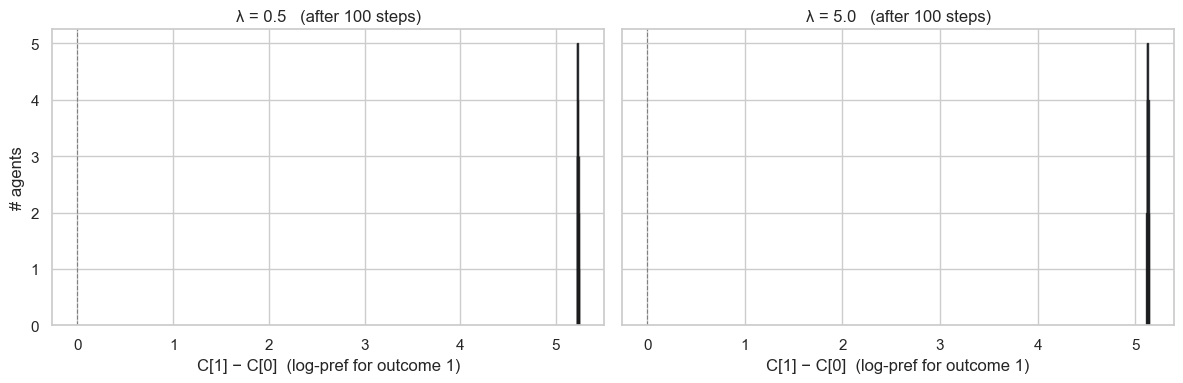

In [7]:
T = 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, lam in zip(axes, [0.5, 5.0]):
    arrs, pop = rollout(
        ModelConfig(lambda_dist=('constant', {'value': lam}), seed=0),
        EnvConfig(n_agents=30, n_contexts=1, seed=0),
        T,
    )
    C = np.asarray(pop.agent.C[0])  # (N, n_obs)
    # Use C[:,1] - C[:,0] as scalar preference (positive = prefer outcome 1)
    pref = C[:, 1] - C[:, 0]
    ax.hist(pref, bins=15, alpha=0.85, edgecolor='k')
    ax.axvline(0, ls='--', c='grey', lw=0.8)
    ax.set(
        xlabel='C[1] − C[0]  (log-pref for outcome 1)',
        title=f'λ = {lam}   (after {T} steps)',
    )
axes[0].set_ylabel('# agents')
plt.tight_layout()
plt.show()

## What to try next

- **Heterogeneous λ** — `lambda_dist=('uniform', {'lo': 0.0, 'hi': 10.0})` lets
  some agents move and others stay rigid. The early-mover dynamics are the
  Bourdieu-flavoured story (lit-review/lit-05).
- **Forward vs reverse drift** — the headline hysteresis figure. Swap the env
  in mid-rollout to a reversed drift trajectory; the loop area is the
  λ-dependent signature.
- **Trust update rate η_γ sensitivity** — how fast does the network forget
  bad predictors? Slower η_γ ↔ stickier social channels.